# Model

We consider the standard linear regression model with covariate matrix $X$ and responses $y$:
\begin{equation}
y | X, \beta, \sigma \sim \mathrm{N}(X \beta, \sigma^{2} I)
\end{equation}
where $\beta$ is the coefficient vector and $\sigma$ is the residual standard deviation. We use the *Bayesian ridge regression* prior, defined as:
\begin{equation}
\beta | \sigma, \lambda \sim \mathrm{N}(0, \sigma^{2} / \lambda), \qquad \sigma^{2} \sim \mathrm{Inverse-Gamma}(.5, .5)
\end{equation}
Where $\lambda$ is the shrinkage parameter. The joint density function of the model is:
\begin{equation}
p(y, \beta, \sigma | X, \lambda) \propto \frac{1}{\sigma^{3 - n - m}} \exp\left[-\frac{\lvert y - X \beta \rvert_{2}^{2} + \lambda \lvert \beta \rvert_{2}^{2} + 1}{2\sigma^{2}}\right]
\end{equation}
where $n$ is the number of observations and $m$ the number of covariates. Since the prior is conjugate, the *evidence* $p(y | X, \lambda)$ is available in closed form. We will use EMUS to estimate $p(y | X, \lambda)$ for a range of values of $\lambda$.

# Experiment

For the simulation study, we generate $X$ as a random matrix of independent standard normal variables. The true parameters $(\beta, \sigma)$ are generated from the prior model with $\lambda = 1$.

# Output

From a vector of windows $(\lambda_{1}, \lambda_{2}, \dots)$ EMUS implements an estimator $\hat{z}$ of the relative evidences:
\begin{equation} 
  z_{i} = \frac{p(y | X, \lambda_{i})}{\sum_{j=1}^{l} p(y | X, \lambda_{j})}, \qquad \sqrt{N}(\hat{z} - z) \overset{N}{\Rightarrow} \mathrm{N}(0, \Sigma_{z})
\end{equation}

In [13]:
# import dependencies

import numpy as np
from scipy.special import logsumexp

from tests import ridge
from emus.tools.qmat import eval_qmat

In [14]:
# set simulation parameters

seed = 0
n_obs = 10
n_vars = 2
cor_x = 0
n_windows = 20
scale_windows = 1.5

In [15]:
# generate fixture

data, param, hyper = ridge.generate_fixture(1, n_obs, n_vars, cor_x, seed)
win = -scale_windows * np.log(1 - np.linspace(0, 1, n_windows + 2)[1:-1])
# win = np.sort([.35, .42, .47, *(6.1 - win)])

log_p = lambda w, the: ridge.eval_logjoint(*data, *the, w, np.ones(1), np.ones(1))
gen_the = lambda w: ridge.param_sampler(*data, w, np.ones(1), np.ones(1))

In [16]:
# compute ground truth

log_z = np.array([ridge.eval_logmargin(*data, w, *hyper[1:]) for w in win])
z = np.exp(log_z - logsumexp(log_z))

# run EMUS adaptively until RMSE is below given value

z_est, z_var, chi, intensity, samples = ridge.est_constant(log_p, gen_the, win, 100, .01, False, True)

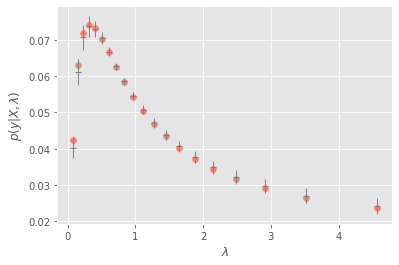

In [17]:
# plot evidence ground truth vs. estimate and 95% CIs
# red markers are true values, black dashes are estimates and black lines are CIs

z_sd = np.sqrt(np.diag(z_var))
ridge.plot_estimate(win, z, z_est, z_sd)

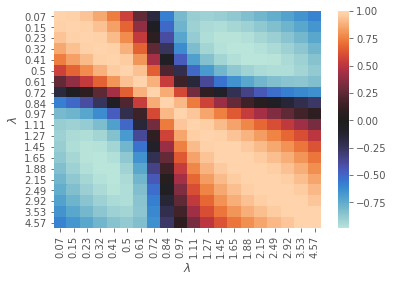

In [18]:
# plot error correlation matrix

z_cor = np.diag(1 / z_sd) @ z_var @ np.diag(1 / z_sd)
ridge.plot_cov(win, z_cor)

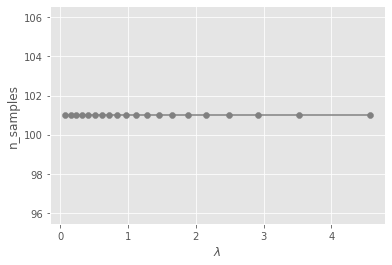

In [19]:
# plot number of samples vs. window value

n_samples = np.array([s.shape[0] for s in samples])
ridge.line_plot(win, n_samples, 'n_samples')

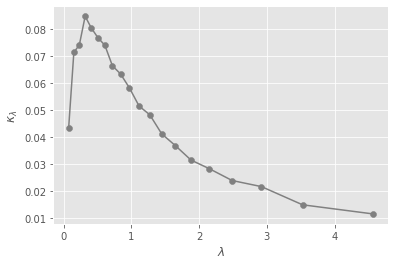

In [20]:
# plot asymptotic sampling rates

ridge.line_plot(win, intensity, '$\\kappa_{\\lambda}$')

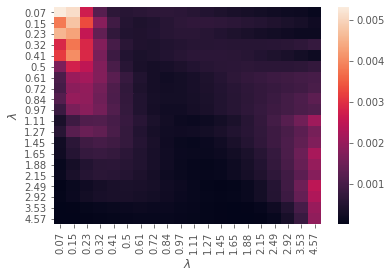

In [21]:
# plot matrix with entries corresponding to estimation variance in elements of the stochastic matrix

r_est = np.array([np.diag(np.cov(np.exp(log_q_.T))) for log_q_ in samples])

ridge.plot_importance(win, r_est)

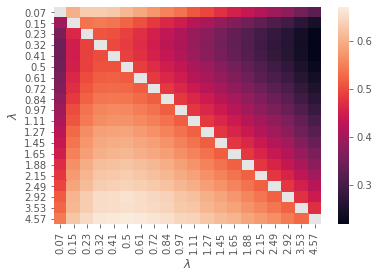

In [22]:
# plot matrix with entries corresponding to the inverse sensitivity of EMUS to estimation error in the stochastic matrix

f_est = np.exp([logsumexp(log_q_, 0) - np.log(log_q_.shape[0]) for log_q_ in samples])
q_est = eval_qmat(f_est)

ridge.plot_importance(win, q_est)

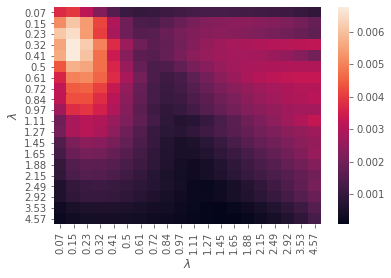

In [23]:
# plot matrix with entries corresponding to the inverse sensitivity of EMUS to estimation error in the stochastic matrix

# plot asymptotic variance coefficients
# rows give the values on which posterior samples are conditioned
# columns give the values on which estimates are conditioned

ridge.plot_importance(win, chi)

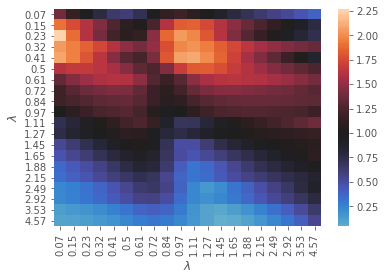

In [24]:
# plot window importances
# rows give the values on which posterior samples are conditioned
# columns give the values on which estimates are conditioned
# sums over columns are normed

importance = chi.shape[0] * chi / np.sum(chi, 0)
ridge.plot_importance(win, importance, 1)